In [3]:
import pandas as pd
import matplotlib.pyplot as plt

day_1_prices = pd.read_csv("../data/prices_round_0_day_-1.csv", sep=";")
day_1_trades = pd.read_csv("../data/trades_round_0_day_-1.csv", sep=";")
day_2_prices = pd.read_csv("../data/prices_round_0_day_-2.csv", sep=";")
day_2_trades = pd.read_csv("../data/trades_round_0_day_-1.csv", sep=";")

day_1_tom_prices = day_1_prices[day_1_prices["product"] == "TOMATOES"].copy()
day_2_tom_prices = day_2_prices[day_2_prices["product"] == "TOMATOES"].copy()
day_1_eme_prices = day_1_prices[day_1_prices["product"] == "EMERALDS"].copy()
day_2_eme_prices = day_2_prices[day_2_prices["product"] == "EMERALDS"].copy()

tom_prices = pd.concat([day_2_tom_prices, day_1_tom_prices])
eme_prices = pd.concat([day_2_eme_prices, day_1_eme_prices])

tom_prices["global_time"] = tom_prices["day"] * 1_000_000 + tom_prices["timestamp"]
eme_prices["global_time"] = eme_prices["day"] * 1_000_000 + eme_prices["timestamp"]

tom_prices = tom_prices.sort_values(["global_time"]).reset_index(drop=True)
eme_prices = eme_prices.sort_values(["global_time"]).reset_index(drop=True)

In [4]:
eme_prices

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_time
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0,-2000000
1,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0,-1999900
2,-2,200,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.0,-1999800
3,-2,300,EMERALDS,9992,13,9990,26,NaN,NaN,10008,13,10010,26,NaN,NaN,10000.0,0.0,-1999700
4,-2,400,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0,-1999600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-1,999500,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0,-500
19996,-1,999600,EMERALDS,9992,14,9990,28,NaN,NaN,10008,14,10010,28,NaN,NaN,10000.0,0.0,-400
19997,-1,999700,EMERALDS,9992,12,9990,26,NaN,NaN,10008,12,10010,26,NaN,NaN,10000.0,0.0,-300
19998,-1,999800,EMERALDS,9992,13,9990,20,NaN,NaN,10008,13,10010,20,NaN,NaN,10000.0,0.0,-200


c:\Users\17rap\OneDrive\Desktop\imc-prosperity-4\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


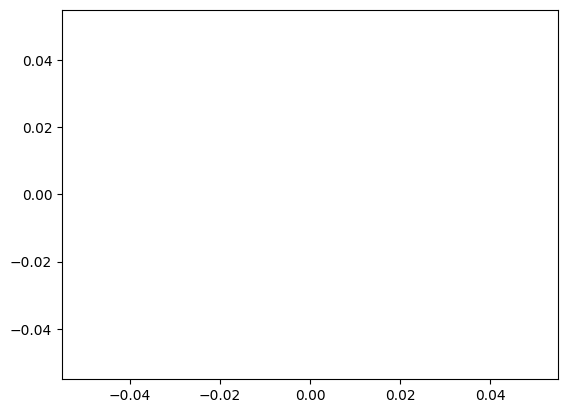

In [9]:
import numpy as np

plt.plot(
    eme_prices["global_time"],
    np.exp(eme_prices["mid_price"])
)